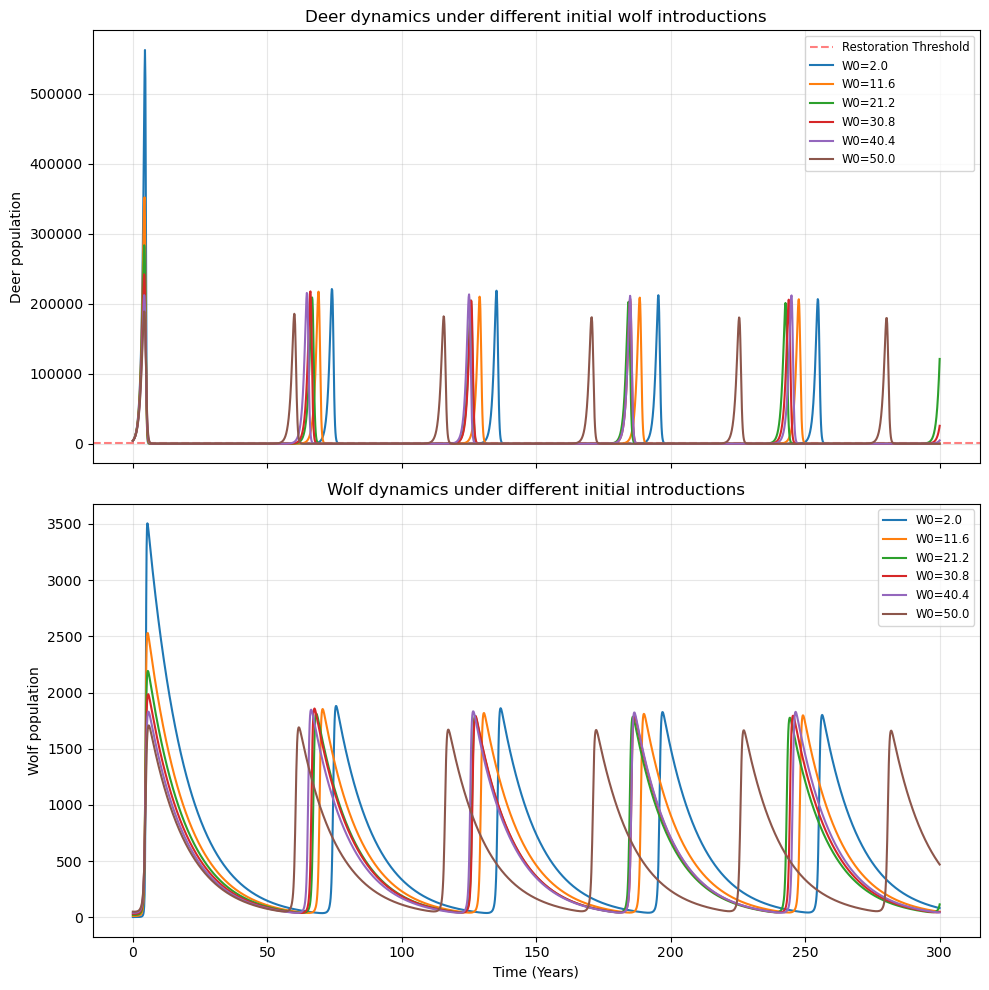

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ODE system
def wolf_deer_model(t, y, params):
    D, W = y
    c, e, beta, d = params
    
    dDdt = (c) * D - e * W * D
    dWdt = beta * e * D * W - d * W
    
    return [dDdt, dWdt]

# Simulation wrapper
def simulate(params, D0, W0, t_max=300):
    t_eval = np.linspace(0, t_max, 2000)
    
    sol = solve_ivp(
        wolf_deer_model,
        [0, t_max],
        [D0, W0],
        args=(params,),
        t_eval=t_eval,
        method='RK45'
    )
    
    return sol.t, sol.y[0], sol.y[1]

# --- Parameters (example placeholders) ---
c = 1.138      # deer birth
e = 17/7000     # predation rate
beta = 0.004   # conversion efficiency
d = 1/14     # wolf death

params = (c, e, beta, d)

# Fixed deer initial population
D0 = 4284

# Sweep wolf initial populations
wolf_initials = np.linspace(2, 50, 6)

# Create a figure with 2 subplots (Deer on top, Wolves on bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Add a hypothetical threshold line for natural woodland restoration (e.g., 1000 deer)
# Adjust this value based on your specific Scottish woodland research
restoration_threshold = 1000 
ax1.axhline(restoration_threshold, color='red', linestyle='--', alpha=0.5, label="Restoration Threshold")

for W0 in wolf_initials:
    t, D, W = simulate(params, D0, W0)
    
    # Plot Deer dynamics
    ax1.plot(t, D, label=f"W0={W0:.1f}")
    
    # Plot Wolf dynamics
    ax2.plot(t, W, label=f"W0={W0:.1f}")

# Format Deer Plot
ax1.set_ylabel("Deer population")
ax1.set_title("Deer dynamics under different initial wolf introductions")
ax1.legend(loc="upper right", fontsize='small')
ax1.grid(True, alpha=0.3)

# Format Wolf Plot
ax2.set_xlabel("Time (Years)")
ax2.set_ylabel("Wolf population")
ax2.set_title("Wolf dynamics under different initial introductions")
ax2.legend(loc="upper right", fontsize='small')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()